# Find out the dimension of interaction blocks between 1st and 2nd layer

## Importing libraries

In [1]:
import torch
from mace import data, modules, tools
import numpy as np
import torch.nn.functional
from e3nn import o3
import ase.io
import matplotlib.pyplot as plt
import warnings
import copy
import pandas as pd
warnings.filterwarnings("ignore")
import logging
logging.basicConfig(level=logging.INFO, format="%(message)s")
import openequivariance

import ns_plots


try:
    import cuequivariance as cue
    cueq_available = True
    print("✓ cuEquivariance library is available")
except ImportError:
    cueq_available = False
    print("✗ cuEquivariance library is not available - cuEq will be disabled")

/homes/ab3149/miniconda3/envs/myvenv/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = torch.l

✓ cuEquivariance library is available


## Get default model configuration to get the right dimensions for the irreps

In [2]:
def get_default_model_config(z_table):
    # setup some default parameters based on the actual dataset
    num_elements = len(z_table.zs)
    # Create atomic energies array with default values for each element
    # You can adjust these values based on your needs
    atomic_energies = np.array([-1.0] * num_elements, dtype=float)  # Default energy per element
    cutoff = 3

    default_model_config = dict(
            num_elements=num_elements,  # number of chemical elements (dynamic)
            atomic_energies=atomic_energies,  # atomic energies used for normalisation
            avg_num_neighbors=8,  # avg number of neighbours of the atoms, used for internal normalisation of messages
            atomic_numbers=z_table.zs,  # atomic numbers, used to specify chemical element embeddings of the model
            r_max=cutoff,  # cutoff
            num_bessel=8,  # number of radial features
            num_polynomial_cutoff=6,  # smoothness of the radial cutoff
            max_ell=2,  # expansion order of spherical harmonic adge attributes
            num_interactions=2,  # number of layers, typically 2
            interaction_cls_first=modules.interaction_classes["RealAgnosticInteractionBlock"],
            interaction_cls=modules.interaction_classes["RealAgnosticInteractionBlock"],
            hidden_irreps=o3.Irreps("8x0e + 8x1o"),  # 8: number of embedding channels, 0e, 1o is specifying which equivariant messages to use. Here up to L_max=1
            correlation=3,  # correlation order of the messages (body order - 1)
            MLP_irreps=o3.Irreps("16x0e"),  # number of hidden dimensions of last layer readout MLP
            gate=torch.nn.functional.silu,  # nonlinearity used in last layer readout MLP
        )

    return default_model_config


def data_prep():
    single_molecule = ase.io.read('md22_double-walled_nanotube.xyz', index='0')

    # Detect elements present in the dataset
    atomic_numbers = single_molecule.numbers
    unique_atomic_numbers = sorted(set(atomic_numbers))
    print(f"Elements found in dataset: {unique_atomic_numbers}")
    print(f"Element symbols: {single_molecule.get_chemical_symbols()[:10]}...")  # Show first 10 symbols
    
    Rcut = 3.0 # cutoff radius
    # z_table = tools.AtomicNumberTable([1, 6, 8])
    z_table = tools.AtomicNumberTable(unique_atomic_numbers)
    print(f"Created z_table with {len(z_table.zs)} elements: {z_table.zs}")

    config = data.Configuration(
        atomic_numbers=single_molecule.numbers,
        positions=single_molecule.positions,
        properties={},
        property_weights={},
    )

    # we handle configurations using the AtomicData class
    batch = data.AtomicData.from_config(config, z_table=z_table, cutoff=Rcut)

    vectors, lengths = modules.utils.get_edge_vectors_and_lengths(
    positions=batch["positions"],
    edge_index=batch["edge_index"],
    shifts=batch["shifts"],
    )
    print(f'there are {batch.positions.shape[0]} nodes and {len(lengths)} edges')
    print(f'lengths is shape {lengths.shape}')
    print(f'vectors is shape {vectors.shape}')

    return batch, lengths, vectors, z_table

### Get a helper function to check the dimensions of the interaction layers (0,1)

In [4]:
from functools import partial

def ensure_ptr_batch_and_no_head(data_dict: dict) -> dict:
    """
    - If 'ptr' missing or None: assume whole thing is one graph, create ptr=[0,N].
    - If 'batch' missing or None: create it via ptr so every atom gets a graph index.
    - If 'head' exists: DROP it, so prepare_graph uses its default zero vector.
    """
    N = int(data_dict["positions"].shape[0])

    # drop any stray head
    data_dict.pop("head", None)

    # ptr
    if "ptr" not in data_dict or data_dict["ptr"] is None:
        data_dict["ptr"] = torch.tensor([0, N], dtype=torch.long,
                                        device=data_dict["positions"].device)

    # batch
    if "batch" not in data_dict or data_dict["batch"] is None:
        ptr = data_dict["ptr"]
        counts = torch.diff(ptr)  # number of atoms per graph
        graph_ids = torch.arange(len(counts), device=ptr.device)
        data_dict["batch"] = torch.repeat_interleave(graph_ids, counts)

    return data_dict


def _print_io(label, module, inp, out):
    in_shapes  = [tuple(t.shape) for t in inp]
    out_shapes = [tuple(o.shape) for o in (out if isinstance(out, tuple) else (out,))]
    print(f"{label:<30s}: {in_shapes}  ->  {out_shapes}")

def _print_pre(label, module, inp):
    in_shapes = [tuple(t.shape) for t in inp]
    print(f"{label:<30s}: (pre) {in_shapes}")

def add_shape_hooks(interaction, idx):
    want = {
        "linear_up",        # first linear 
        "conv_tp_weights",  # radial MLP
        "conv_tp",          # TP message
        "linear",           # post-aggregate linear
    }
    for name, sub in interaction.named_modules():
        if name in want:
            # show pre-aggregate on 'linear'
            if name == "linear":
                sub.register_forward_pre_hook(
                    partial(_print_pre, f"[L{idx}] {name}")
                )
            sub.register_forward_hook(
                partial(_print_io, f"[L{idx}] {name}")
            )


def trace_shapes(device="cpu"):
    # ---- prepare data ----
    batch, lengths, vectors, z_table = data_prep()  # your data_prep
    if hasattr(batch, "to_dict"):                    # PyG Batch?
        batch = batch.to_dict()
    batch = ensure_ptr_batch_and_no_head(batch)

    # ---- build model ----
    torch.set_default_dtype(torch.float64)
    cfg   = get_default_model_config(z_table)        # your config fn
    model = modules.MACE(**cfg).to(device=device,
                                   dtype=torch.float64)

    # ---- list sub-modules once ----
    print("\n--- interaction[0] sub-modules ---")
    for n, _ in model.interactions[0].named_modules():
        print(" ", n)
    print("-------------------------------------\n")

    # ---- attach hooks & run ----
    add_shape_hooks(model.interactions[0], idx=0)
    add_shape_hooks(model.interactions[1], idx=1)
    _ = model(batch)  # prints all the shapes


# finally, run it
trace_shapes(device="cpu")

Elements found in dataset: [np.int64(1), np.int64(6)]
Element symbols: ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']...
Created z_table with 2 elements: [np.int64(1), np.int64(6)]
there are 370 nodes and 4270 edges
lengths is shape torch.Size([4270, 1])
vectors is shape torch.Size([4270, 3])

--- interaction[0] sub-modules ---
  
  linear_up
  linear_up._compiled_main
  conv_tp
  conv_tp._compiled_main_left_right
  conv_tp._compiled_main_right
  conv_tp_weights
  conv_tp_weights.layer0
  conv_tp_weights.layer0.act
  conv_tp_weights.layer1
  conv_tp_weights.layer2
  conv_tp_weights.layer3
  linear
  linear._compiled_main
  skip_tp
  skip_tp._compiled_main_left_right
  skip_tp._compiled_main_right
  reshape
-------------------------------------

[L0] linear_up                : [(370, 8)]  ->  [(370, 8)]
[L0] conv_tp_weights          : [(4270, 8)]  ->  [(4270, 24)]
[L0] conv_tp                  : [(4270, 8), (4270, 9), (4270, 24)]  ->  [(4270, 72)]
[L0] linear                   : (pr

---

## This test the difference of computational cost between layer 0 and layer 2

Here we are just checking the computational cost in GPU and wall-time

In [5]:
import types

def with_cueq_conv_fusion(conv_tp: torch.nn.Module) -> torch.nn.Module:
    """Wraps a cuet.ConvTensorProduct to use conv fusion"""
    conv_tp.original_forward = conv_tp.forward

    def forward(
        self,
        node_feats: torch.Tensor,
        edge_attrs: torch.Tensor,
        tp_weights: torch.Tensor,
        edge_index: torch.Tensor,
    ) -> torch.Tensor:
        sender = edge_index[0]
        receiver = edge_index[1]
        return self.original_forward(
            [tp_weights, node_feats, edge_attrs],
            {1: sender},
            {0: node_feats},
            {0: receiver},
        )

    conv_tp.forward = types.MethodType(forward, conv_tp)
    return conv_tp

In [6]:
def get_memory_and_time_usage(device: str, task_name: callable):
    if device.startswith('cuda'):

        torch.cuda.reset_peak_memory_stats(device)
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        task_name
        end.record()
        torch.cuda.synchronize()
        t = start.elapsed_time(end)
        m = torch.cuda.max_memory_allocated(device)
        return t, m
    else:
        import time
        t = time.perf_counter()
        task_name()
        t = (time.perf_counter() - t) * 1000
        m = 0
        return t, m

### Creates functions for our benchmark

In [7]:
import torch, copy
from e3nn.o3 import Irreps
import cuequivariance   as cue
import cuequivariance_torch as cuet

def benchmark_cuda(fn, warmup=10, runs=50):

    # we should run once under no grad so the kenel is JIT-compiled
    with torch.inference_mode():
        fn()
    torch.cuda.synchronize()

    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()

    torch.cuda.reset_peak_memory_stats()

    time_ms = []
    for _ in range(runs):
        start = torch.cuda.Event(enable_timing=True)
        end   = torch.cuda.Event(enable_timing=True)
        start.record()
        fn()
        end.record()
        torch.cuda.synchronize()
        time_ms.append(start.elapsed_time(end))

    mean_time_ms = (sum(time_ms)/len(time_ms))
    peak_mem_bytes = torch.cuda.max_memory_allocated()
    return mean_time_ms, peak_mem_bytes

def benchmark_cpu(fn, warmup=3, runs=10):
    import time
    for _ in range(warmup):
        fn()
    t0 = time.perf_counter()
    for _ in range(runs):
        fn()
    return (time.perf_counter()-t0)*1000/runs, 0

def get_memory_and_time_usage(device: str, fn):
    return (benchmark_cuda if device.startswith("cuda") else benchmark_cpu)(fn)



### grab the tensorproduct modules because we want to get the dimensions of the weights and also the right dimensino for irreps

In [8]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
torch.manual_seed(0)

batch, lengths, vectors, z_table = data_prep()
cfg   = get_default_model_config(z_table)
model = modules.MACE(**cfg).to(device=device, dtype=torch.float64)

# grab the two TensorProduct modules because we want to get the dimensions of the weights
tp0 = model.interactions[0].conv_tp # first layer
tp1 = model.interactions[1].conv_tp # second layer

# turn their irreps into e3nn.Irreps to get dimensions
in_ir0, attr_ir0, out_ir0 = (
    Irreps(tp0.irreps_in1),
    Irreps(tp0.irreps_in2),
    Irreps(tp0.irreps_out),
)
in_ir1, attr_ir1, out_ir1 = (
    Irreps(tp1.irreps_in1),
    Irreps(tp1.irreps_in2),
    Irreps(tp1.irreps_out),
)

# sanity check printing

print("L0 output dim:", out_ir0.dim)
print("L1 output dim:", out_ir1.dim)

print("Layer 0 conv_tp dims:")
print(" - in feat dim        ", in_ir0.dim)
print(" - edge-attr (Y_l) dim ", attr_ir0.dim)
print(" - radial-MLP weight dim", tp0.weight_numel)
print(" - out feat dim       ", out_ir0.dim, "\n")

print("Layer 1 conv_tp dims:")
print(" - in feat dim        ", in_ir1.dim)
print(" - edge-attr (Y_l) dim ", attr_ir1.dim)
print(" - radial-MLP weight dim", tp1.weight_numel)
print(" - out feat dim       ", out_ir1.dim, "\n")


Using device: cuda
Elements found in dataset: [np.int64(1), np.int64(6)]
Element symbols: ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']...
Created z_table with 2 elements: [np.int64(1), np.int64(6)]
there are 370 nodes and 4270 edges
lengths is shape torch.Size([4270, 1])
vectors is shape torch.Size([4270, 3])
L0 output dim: 72
L1 output dim: 168
Layer 0 conv_tp dims:
 - in feat dim         8
 - edge-attr (Y_l) dim  9
 - radial-MLP weight dim 24
 - out feat dim        72 

Layer 1 conv_tp dims:
 - in feat dim         32
 - edge-attr (Y_l) dim  9
 - radial-MLP weight dim 56
 - out feat dim        168 



### Build the segmented polynomial in math_dtype fp64

We build our first benchmark for GPU and wall-time using the low-level implementation of conv_fusion which is using in the background cue and cuet functions. They can only be activated with a math_dtype:
- float64
- float32

The Inputs/Outputs (I/O) can be converted in different numerical precisions
- fp64
- fp32
- tf32
- bf16
- fp16

### make_poly is a function that builds the descriptor and the polynomial class

In [9]:
# build cue descriptors + polynomial modules which allows us to use the cuequivariance library and directly conv_tp without
# having to write our own custom conv_tp config file which is annoying atm
def make_poly(in_ir, attr_ir, out_ir, math_dtype):
    desc = cue.descriptors.channelwise_tensor_product(
        cue.Irreps("O3", in_ir),
        cue.Irreps("O3", attr_ir),
        cue.Irreps("O3", out_ir),
    )
    return cuet.SegmentedPolynomial(
        desc.flatten_coefficient_modes()
            .squeeze_modes()
            .polynomial,
        math_dtype=math_dtype,
        output_dtype_map=[-1]
    ).to(device)


testing in fp64

In [10]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
torch.manual_seed(0)

# we are building for the first layer and second layer
poly0 = make_poly(in_ir0, attr_ir0, out_ir0, math_dtype=torch.float64)
poly1 = make_poly(in_ir1, attr_ir1, out_ir1, math_dtype=torch.float64)

# fuse them with the helper function which is given by MACE in wrapper_ops.py
fused0_ref = with_cueq_conv_fusion(poly0)
fused1_ref = with_cueq_conv_fusion(poly1)

# cast layers once and store dtype
layers0, layers1 = {}, {}
for name, dtype in [
    ("FP64", torch.float64),
    ("FP32", torch.float32),
    ("TF32","tf32"),
    ("FP16", torch.float16),
    ("BF16", torch.bfloat16),
]:
    if name in ("FP64","FP32","FP16","BF16") and device.startswith("cuda"):
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32   = False
    if name == "TF32" and device.startswith("cuda"):
        dtype = torch.float32
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32   = True

    m0 = copy.deepcopy(fused0_ref).to(dtype)
    m1 = copy.deepcopy(fused1_ref).to(dtype)
    layers0[name] = (m0, dtype)
    layers1[name] = (m1, dtype)

# simulate a mini-batch with the same number of nodes and edges as the real run
N, E = 200000, 2000000
nf0 = torch.randn(N, in_ir0.dim,    dtype=torch.float64)
nf1 = torch.randn(N, in_ir1.dim,    dtype=torch.float64)
ea  = torch.randn(E, attr_ir0.dim,  dtype=torch.float64)
tw0 = torch.randn(E, tp0.weight_numel, dtype=torch.float64)
tw1 = torch.randn(E, tp1.weight_numel, dtype=torch.float64)
ei  = torch.randint(0, N, (2, E), dtype=torch.int64)

inputs0, inputs1 = {}, {}
for name, (layer0, dt0) in layers0.items():
    inputs0[name] = (
        nf0.to(device=device, dtype=dt0),
        ea .to(device=device, dtype=dt0),
        tw0.to(device=device, dtype=dt0),
        ei .to(device)
    )
    layer1, dt1 = layers1[name]
    inputs1[name] = (
        nf1.to(device=device, dtype=dt1),
        ea .to(device=device, dtype=dt1),
        tw1.to(device=device, dtype=dt1),
        ei .to(device)
    )

# benchmark forward only
results = []
for name in layers0:
    layer0, _ = layers0[name]
    layer1, _ = layers1[name]

    task0 = lambda: layer0(*inputs0[name])[0]
    task1 = lambda: layer1(*inputs1[name])[0]

    t0, m0 = get_memory_and_time_usage(device, task0)
    t1, m1 = get_memory_and_time_usage(device, task1)
    results.append((name, t0, m0, t1, m1))

# Convert results to DataFrame
df_results = pd.DataFrame(results, columns=['dtype', 'L0_time', 'L0_mem', 'L1_time', 'L1_mem'])
df_results['L0_time'] = df_results['L0_time'].round(3)
df_results['L1_time'] = df_results['L1_time'].round(3)
df_results['L0_mem'] = (df_results['L0_mem'] / 1e6).round(3)
df_results['L1_mem'] = (df_results['L1_mem'] / 1e6).round(3)
df_results['L1/L0_time'] = (df_results['L1_time'] / df_results['L0_time']).round(3)
df_results['L1/L0_mem'] = (df_results['L1_mem'] / df_results['L0_mem']).round(3)

# Display the DataFrame
print("Benchmark Results when cuet.SegmentedPolynomial is used in math_dtype: fp64. All results are in ms and MB")
print(df_results.to_string(index=False))



Using device: cuda
Benchmark Results when cuet.SegmentedPolynomial is used in math_dtype: fp64. All results are in ms and MB
dtype  L0_time  L0_mem  L1_time   L1_mem  L1/L0_time  L1/L0_mem
 FP64    6.787 4522.67   24.921 4676.127       3.672      1.034
 FP32    9.411 4522.67   30.922 4676.127       3.286      1.034
 TF32    9.423 4522.67   30.984 4676.127       3.288      1.034
 FP16    9.363 4522.67   31.216 4676.127       3.334      1.034
 BF16    9.374 4522.67   30.996 4676.127       3.307      1.034


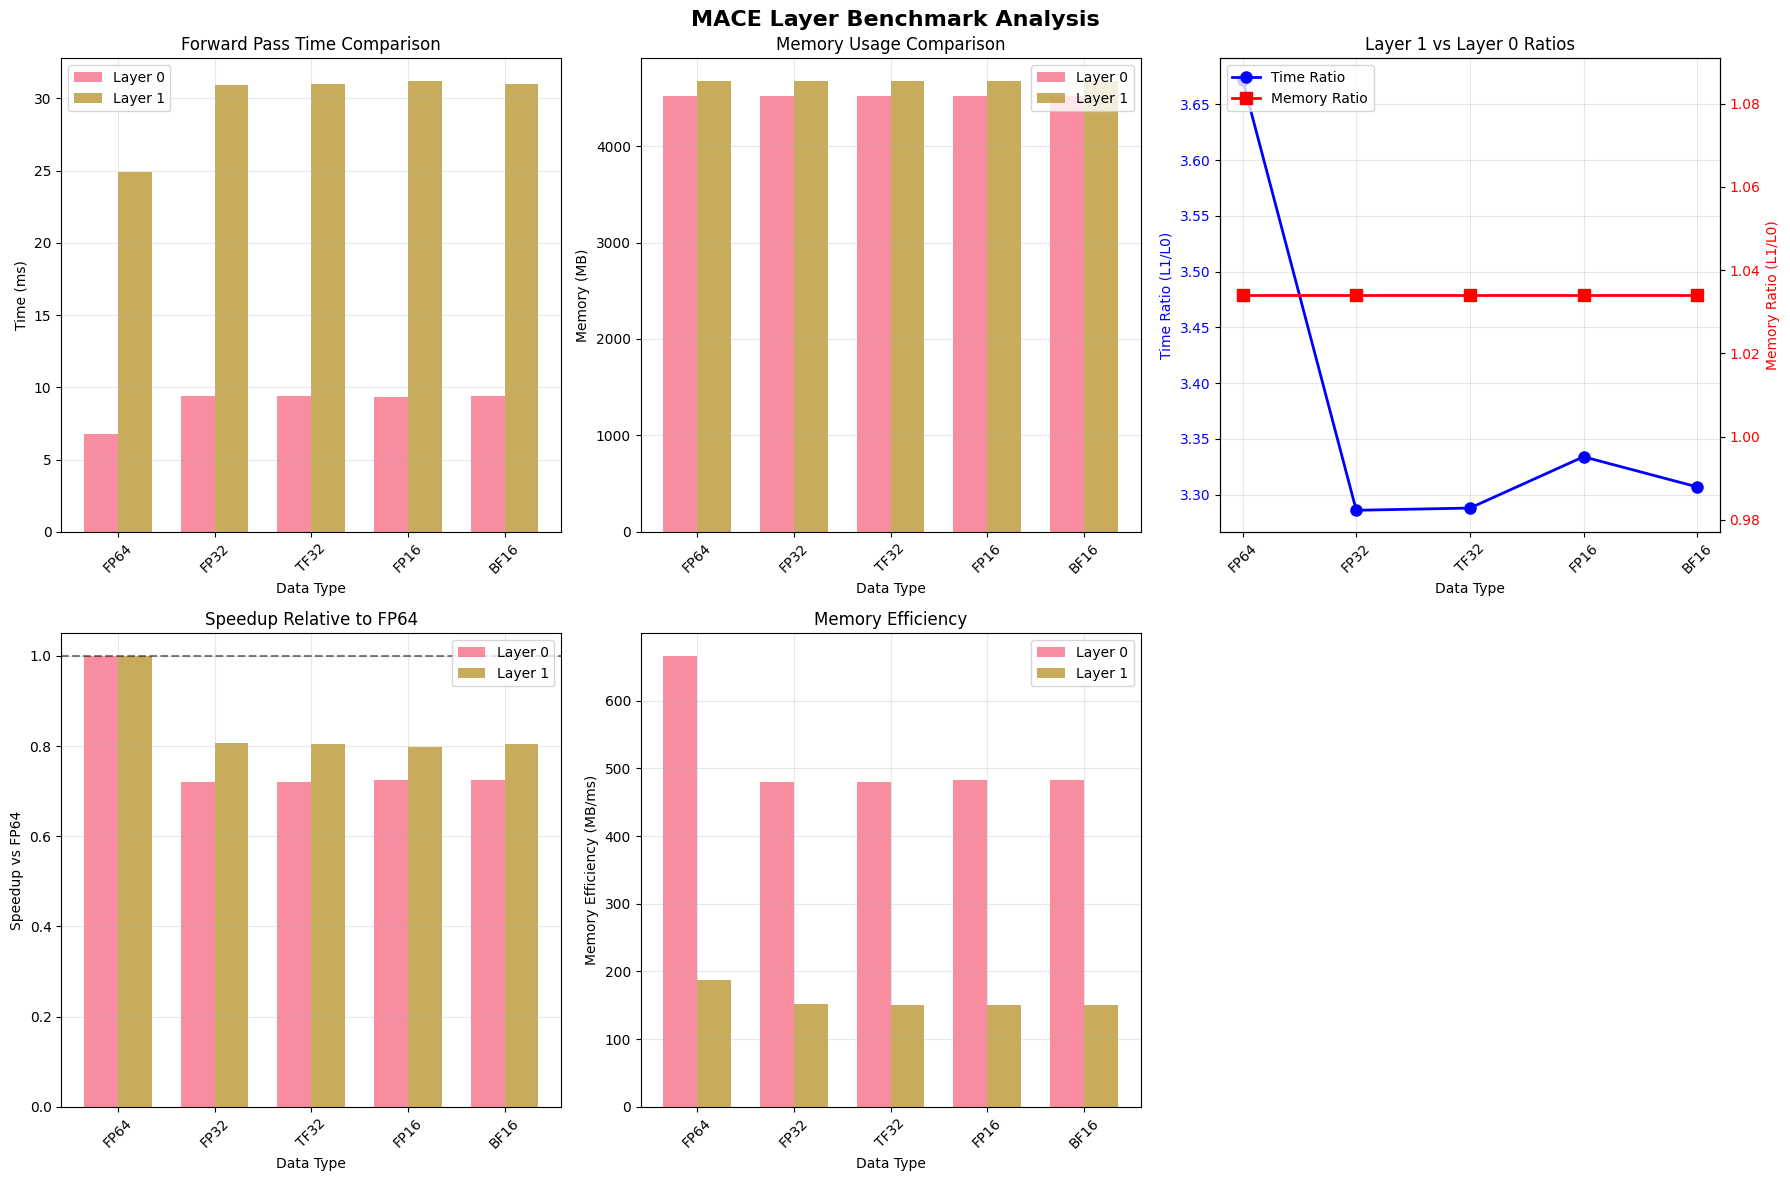


SUMMARY STATISTICS

Fastest Layer 0: FP64 (6.787 ms)
Fastest Layer 1: FP64 (24.921 ms)

Most Memory Efficient Layer 0: FP64 (4522.670 MB)
Most Memory Efficient Layer 1: FP64 (4676.127 MB)

Layer 1 is on average 3.38x slower than Layer 0
Layer 1 uses on average 1.03x more memory than Layer 0

Speedup vs FP64 (Layer 0):
  FP64: 1.00x
  FP32: 0.72x
  TF32: 0.72x
  FP16: 0.72x
  BF16: 0.72x

Speedup vs FP64 (Layer 1):
  FP64: 1.00x
  FP32: 0.81x
  TF32: 0.80x
  FP16: 0.80x
  BF16: 0.80x


In [11]:
import plotting_code as pc

pc.create_benchmark_plots(df_results)
pc.print_summary_statistics(df_results)

### Build the segmented polynomial in math_dtype fp32

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
torch.manual_seed(0)

# we are building for the first layer and second layer
poly0 = make_poly(in_ir0, attr_ir0, out_ir0, math_dtype=torch.float32)
poly1 = make_poly(in_ir1, attr_ir1, out_ir1, math_dtype=torch.float32)

# fuse them with the helper function which is given by MACE in wrapper_ops.py
fused0_ref = with_cueq_conv_fusion(poly0)
fused1_ref = with_cueq_conv_fusion(poly1)

# cast layers once and store dtype
layers0, layers1 = {}, {}
for name, dtype in [
    ("FP64", torch.float64),
    ("FP32", torch.float32),
    ("TF32","tf32"),
    ("FP16", torch.float16),
    ("BF16", torch.bfloat16),
]:
    if name in ("TF32","FP16","BF16") and not device.startswith("cuda"):
        continue
    if name == "TF32" and device.startswith("cuda"):
        dtype = torch.float32
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32   = True

    m0 = copy.deepcopy(fused0_ref).to(dtype)
    m1 = copy.deepcopy(fused1_ref).to(dtype)
    layers0[name] = (m0, dtype)
    layers1[name] = (m1, dtype)

# simulate a mini-batch with the same number of nodes and edges as the real run
N, E = 200000, 2000000
nf0 = torch.randn(N, in_ir0.dim,    dtype=torch.float64)
nf1 = torch.randn(N, in_ir1.dim,    dtype=torch.float64)
ea  = torch.randn(E, attr_ir0.dim,  dtype=torch.float64)
tw0 = torch.randn(E, tp0.weight_numel, dtype=torch.float64)
tw1 = torch.randn(E, tp1.weight_numel, dtype=torch.float64)
ei  = torch.randint(0, N, (2, E), dtype=torch.int64)

inputs0, inputs1 = {}, {}
for name, (layer0, dt0) in layers0.items():
    inputs0[name] = (
        nf0.to(device=device, dtype=dt0),
        ea .to(device=device, dtype=dt0),
        tw0.to(device=device, dtype=dt0),
        ei .to(device)
    )
    layer1, dt1 = layers1[name]
    inputs1[name] = (
        nf1.to(device=device, dtype=dt1),
        ea .to(device=device, dtype=dt1),
        tw1.to(device=device, dtype=dt1),
        ei .to(device)
    )

# benchmark forward only
results = []
for name in layers0:
    layer0, _ = layers0[name]
    layer1, _ = layers1[name]

    task0 = lambda: layer0(*inputs0[name])[0]
    task1 = lambda: layer1(*inputs1[name])[0]

    t0, m0 = get_memory_and_time_usage(device, task0)
    t1, m1 = get_memory_and_time_usage(device, task1)
    results.append((name, t0, m0, t1, m1))

# Convert results to DataFrame
df_results = pd.DataFrame(results, columns=['dtype', 'L0_time', 'L0_mem', 'L1_time', 'L1_mem'])
df_results['L0_time'] = df_results['L0_time'].round(3)
df_results['L1_time'] = df_results['L1_time'].round(3)
df_results['L0_mem'] = (df_results['L0_mem'] / 1e6).round(3)
df_results['L1_mem'] = (df_results['L1_mem'] / 1e6).round(3)
df_results['L1/L0_time'] = (df_results['L1_time'] / df_results['L0_time']).round(3)
df_results['L1/L0_mem'] = (df_results['L1_mem'] / df_results['L0_mem']).round(3)

# Display the DataFrame
print("Benchmark Results when cuet.SegmentedPolynomial is used in math_dtype: fp32")
print(df_results.to_string(index=False))



Using device: cuda
Benchmark Results when cuet.SegmentedPolynomial is used in math_dtype: fp32
dtype  L0_time   L0_mem  L1_time   L1_mem  L1/L0_time  L1/L0_mem
 FP64    4.684 4464.927    9.039 4541.727       1.930      1.017
 FP32    4.200 4464.927    7.897 4541.727       1.880      1.017
 TF32    4.199 4464.927    7.906 4541.727       1.883      1.017
 FP16    4.056 4464.927    7.479 4541.727       1.844      1.017
 BF16    4.054 4464.927    7.496 4541.727       1.849      1.017


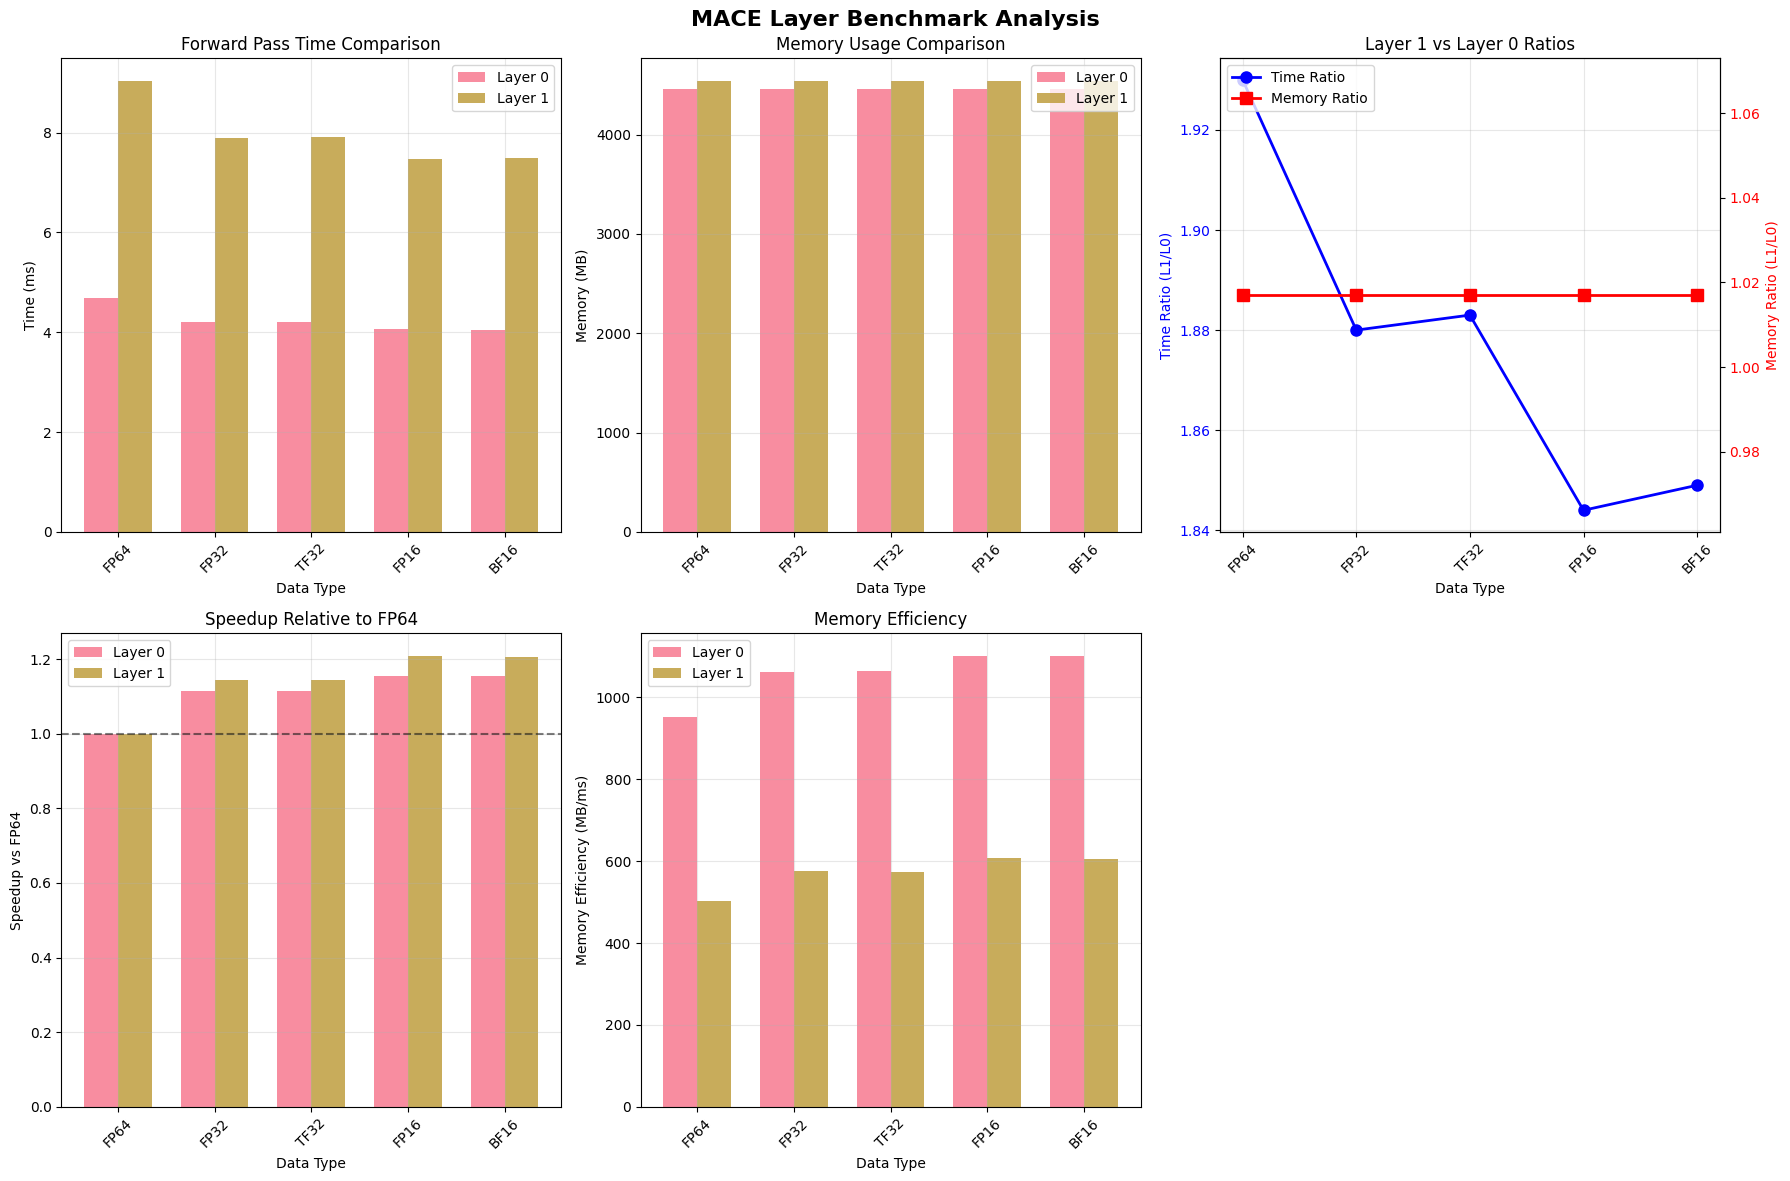


SUMMARY STATISTICS

Fastest Layer 0: BF16 (4.054 ms)
Fastest Layer 1: FP16 (7.479 ms)

Most Memory Efficient Layer 0: FP64 (4464.927 MB)
Most Memory Efficient Layer 1: FP64 (4541.727 MB)

Layer 1 is on average 1.88x slower than Layer 0
Layer 1 uses on average 1.02x more memory than Layer 0

Speedup vs FP64 (Layer 0):
  FP64: 1.00x
  FP32: 1.12x
  TF32: 1.12x
  FP16: 1.15x
  BF16: 1.16x

Speedup vs FP64 (Layer 1):
  FP64: 1.00x
  FP32: 1.14x
  TF32: 1.14x
  FP16: 1.21x
  BF16: 1.21x


In [13]:
import plotting_code as pc

pc.create_benchmark_plots(df_results)
pc.print_summary_statistics(df_results)

## Build numerical precision benchmark

We have are now going to build our numerical precision benchmark which is essentially comparing our default numerical precision (fp64) to all the others by calculating:
- the error
- the relative error

we perform both **forward** and **backward** pass for each layers of the interaction blocks

We define here a simple loss function for the backward step

In [14]:
def loss_fn(out):
    return out.pow(2).sum()

### For now the graph is sparse

The edge dimension is (2, E)

### Build the segmented polynomial in math_dtype fp64

In [16]:
# TODO: the initiation of a random graph can bring some numerical instability so we should create different graphs and average the results

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
torch.manual_seed(0)

# we are building for the first layer and second layer
poly0 = make_poly(in_ir0, attr_ir0, out_ir0, math_dtype=torch.float64)
poly1 = make_poly(in_ir1, attr_ir1, out_ir1, math_dtype=torch.float64)

# fuse them with the helper function which is given by MACE in wrapper_ops.py
fused0_ref = with_cueq_conv_fusion(poly0)
fused1_ref = with_cueq_conv_fusion(poly1)

# cast layers once and store dtype
layers0, layers1 = {}, {}
for name, dtype in [
    ("FP64", torch.float64),
    ("FP32", torch.float32),
    ("TF32", torch.float32),
    ("FP16", torch.float16),
    ("BF16", torch.bfloat16),
]:
    torch.backends.cuda.matmul.allow_tf32 = (name == "TF32")
    torch.backends.cudnn.allow_tf32 = (name == "TF32")
        

    m0 = copy.deepcopy(fused0_ref).to(dtype)
    m1 = copy.deepcopy(fused1_ref).to(dtype)
    layers0[name] = (m0, dtype)
    layers1[name] = (m1, dtype)

# simulate a mini-batch with the same number of nodes and edges as the real run
N, E = 200000, 2000000
nf0_base = torch.randn(N, in_ir0.dim,    dtype=torch.float64)
nf1_base = torch.randn(N, in_ir1.dim,    dtype=torch.float64)
ea_base  = torch.randn(E, attr_ir0.dim,  dtype=torch.float64)
tw0_base = torch.randn(E, tp0.weight_numel, dtype=torch.float64)
tw1_base = torch.randn(E, tp1.weight_numel, dtype=torch.float64)
ei_base  = torch.randint(0, N, (2, E), dtype=torch.int64)

inputs0, inputs1 = {}, {}
for name, (layer0, dt0) in layers0.items():
    inputs0[name] = (
        nf0_base.clone().to(device=device, dtype=dt0).requires_grad_(),
        ea_base.clone().to(device=device, dtype=dt0),
        tw0_base.clone().to(device=device, dtype=dt0),
        ei_base.to(device)
    )
    layer1, dt1 = layers1[name]
    inputs1[name] = (
        nf1_base.clone().to(device=device, dtype=dt1).requires_grad_(),
        ea_base.clone().to(device=device, dtype=dt1),
        tw1_base.clone().to(device=device, dtype=dt1),
        ei_base.to(device)
    )

# benchmark forward and backward
# Run FP64 first (reference)
layer0_fp64, _ = layers0["FP64"]
layer1_fp64, _ = layers1["FP64"]

results = {0: {}, 1: {}}

# Layer 0 FP64
out0_fp64 = layer0_fp64(*inputs0["FP64"])[0]
loss0_fp64 = loss_fn(out0_fp64)
loss0_fp64.backward()
grad0_fp64 = inputs0["FP64"][0].grad.detach().cpu().numpy()
out0_fp64 = out0_fp64.detach().cpu().numpy()
results[0]["FP64"] = {'out': out0_fp64, 'grad': grad0_fp64}

# clear gradients
for p in layer0_fp64.parameters():
    if p.grad is not None:
        p.grad = None
inputs0["FP64"][0].grad = None

# Layer 1 FP64
out1_fp64 = layer1_fp64(*inputs1["FP64"])[0]
loss1_fp64 = loss_fn(out1_fp64)
loss1_fp64.backward()
grad1_fp64 = inputs1["FP64"][0].grad.detach().cpu().numpy()
out1_fp64 = out1_fp64.detach().cpu().numpy()
results[1]["FP64"] = {'out': out1_fp64, 'grad': grad1_fp64}

# clear gradients
for p in layer1_fp64.parameters():
    if p.grad is not None:
        p.grad = None
inputs1["FP64"][0].grad = None


# Run FP32 and compare
layer0_fp32, _ = layers0["FP32"]
layer1_fp32, _ = layers1["FP32"]

# Layer 0 FP32
out0_fp32 = layer0_fp32(*inputs0["FP32"])[0]
loss0_fp32 = loss_fn(out0_fp32)
loss0_fp32.backward()
grad0_fp32 = inputs0["FP32"][0].grad.detach().cpu().numpy()
out0_fp32 = out0_fp32.detach().cpu().numpy()
results[0]["FP32"] = {'out': out0_fp32, 'grad': grad0_fp32}

# clear gradients
for p in layer0_fp32.parameters():
    if p.grad is not None:
        p.grad = None
inputs0["FP32"][0].grad = None

# Layer 1 FP32
out1_fp32 = layer1_fp32(*inputs1["FP32"])[0]
loss1_fp32 = loss_fn(out1_fp32)
loss1_fp32.backward()
grad1_fp32 = inputs1["FP32"][0].grad.detach().cpu().numpy()
out1_fp32 = out1_fp32.detach().cpu().numpy()
results[1]["FP32"] = {'out': out1_fp32, 'grad': grad1_fp32}

# clear gradients
for p in layer1_fp32.parameters():
    if p.grad is not None:
        p.grad = None
inputs1["FP32"][0].grad = None

# Run TF32 and compare
layer0_tf32, _ = layers0["TF32"]
layer1_tf32, _ = layers1["TF32"]

# Layer 0 TF32
out0_tf32 = layer0_tf32(*inputs0["TF32"])[0]
loss0_tf32 = loss_fn(out0_tf32)
loss0_tf32.backward()
grad0_tf32 = inputs0["TF32"][0].grad.detach().cpu().numpy()
out0_tf32 = out0_tf32.detach().cpu().numpy()
results[0]["TF32"] = {'out': out0_tf32, 'grad': grad0_tf32}

# clear gradients
for p in layer0_tf32.parameters():
    if p.grad is not None:
        p.grad = None
inputs0["TF32"][0].grad = None

# Layer 1 TF32
out1_tf32 = layer1_tf32(*inputs1["TF32"])[0]
loss1_tf32 = loss_fn(out1_tf32)
loss1_tf32.backward()
grad1_tf32 = inputs1["TF32"][0].grad.detach().cpu().numpy()
out1_tf32 = out1_tf32.detach().cpu().numpy()
results[1]["TF32"] = {'out': out1_tf32, 'grad': grad1_tf32}

# clear gradients
for p in layer1_tf32.parameters():
    if p.grad is not None:
        p.grad = None
inputs1["TF32"][0].grad = None

# Run FP16 and compare
layer0_fp16, _ = layers0["FP16"]
layer1_fp16, _ = layers1["FP16"]

# Layer 0 FP16
out0_fp16 = layer0_fp16(*inputs0["FP16"])[0]
loss0_fp16 = loss_fn(out0_fp16)
loss0_fp16.backward()
grad0_fp16 = inputs0["FP16"][0].grad.detach().float().cpu().numpy()
out0_fp16 = out0_fp16.detach().float().cpu().numpy()
results[0]["FP16"] = {'out': out0_fp16, 'grad': grad0_fp16}

# clear gradients
for p in layer0_fp16.parameters():
    if p.grad is not None:
        p.grad = None
inputs0["FP16"][0].grad = None

# Layer 1 FP16
out1_fp16 = layer1_fp16(*inputs1["FP16"])[0]
loss1_fp16 = loss_fn(out1_fp16)
loss1_fp16.backward()
grad1_fp16 = inputs1["FP16"][0].grad.detach().float().cpu().numpy()
out1_fp16 = out1_fp16.detach().float().cpu().numpy()
results[1]["FP16"] = {'out': out1_fp16, 'grad': grad1_fp16}

# clear gradients
for p in layer1_fp16.parameters():
    if p.grad is not None:
        p.grad = None
inputs1["FP16"][0].grad = None

# Run BF16 and compare
layer0_bf16, _ = layers0["BF16"]
layer1_bf16, _ = layers1["BF16"]

# Layer 0 BF16
out0_bf16 = layer0_bf16(*inputs0["BF16"])[0]
loss0_bf16 = loss_fn(out0_bf16)
loss0_bf16.backward()
grad0_bf16 = inputs0["BF16"][0].grad.detach().float().cpu().numpy()
out0_bf16 = out0_bf16.detach().float().cpu().numpy()
results[0]["BF16"] = {'out': out0_bf16, 'grad': grad0_bf16}

# clear gradients
for p in layer0_bf16.parameters():
    if p.grad is not None:
        p.grad = None
inputs0["BF16"][0].grad = None

# Layer 1 BF16
out1_bf16 = layer1_bf16(*inputs1["BF16"])[0]
loss1_bf16 = loss_fn(out1_bf16)
loss1_bf16.backward()
grad1_bf16 = inputs1["BF16"][0].grad.detach().float().cpu().numpy()
out1_bf16 = out1_bf16.detach().float().cpu().numpy()
results[1]["BF16"] = {'out': out1_bf16, 'grad': grad1_bf16}

# clear gradients
for p in layer1_bf16.parameters():
    if p.grad is not None:
        p.grad = None
inputs1["BF16"][0].grad = None

# Compare FP64 vs FP32, TF32, FP16, BF16 for each layer

# Layer 0   
print("Layer 0 (FP64 vs FP32 vs TF32 vs FP16 vs BF16):")
out0_err = np.abs(results[0]["FP64"]['out'] - results[0]["FP32"]['out'])
out0_rel = np.abs(out0_err / (np.abs(results[0]["FP64"]['out']) + 1e-6))
grad0_err = np.abs(results[0]["FP64"]['grad'] - results[0]["FP32"]['grad'])
grad0_rel = np.abs(grad0_err / (np.abs(results[0]["FP64"]['grad']) + 1e-6))

out0_err_tf32 = np.abs(results[0]["FP64"]['out'] - results[0]["TF32"]['out'])
out0_rel_tf32 = np.abs(out0_err_tf32 / (np.abs(results[0]["FP64"]['out']) + 1e-6))
grad0_err_tf32 = np.abs(results[0]["FP64"]['grad'] - results[0]["TF32"]['grad'])
grad0_rel_tf32 = np.abs(grad0_err_tf32 / (np.abs(results[0]["FP64"]['grad']) + 1e-6))

out0_err_fp16 = np.abs(results[0]["FP64"]['out'] - results[0]["FP16"]['out'])
out0_rel_fp16 = np.abs(out0_err_fp16 / (np.abs(results[0]["FP64"]['out']) + 1e-6))
grad0_err_fp16 = np.abs(results[0]["FP64"]['grad'] - results[0]["FP16"]['grad'])
grad0_rel_fp16 = np.abs(grad0_err_fp16 / (np.abs(results[0]["FP64"]['grad']) + 1e-6))

out0_err_bf16 = np.abs(results[0]["FP64"]['out'] - results[0]["BF16"]['out'])
out0_rel_bf16 = np.abs(out0_err_bf16 / (np.abs(results[0]["FP64"]['out']) + 1e-6))
grad0_err_bf16 = np.abs(results[0]["FP64"]['grad'] - results[0]["BF16"]['grad'])
grad0_rel_bf16 = np.abs(grad0_err_bf16 / (np.abs(results[0]["FP64"]['grad']) + 1e-6))


comparison_data = []
for metric in ['forward', 'backward']:
    idx = 0 if metric == 'forward' else 1
    
    # FP32 comparison
    comparison_data.append({
        'metric': metric,
        'precision': 'FP32',
        'max_abs_error': out0_err.max() if metric == 'forward' else grad0_err.max(),
        'max_rel_error': out0_rel.max() if metric == 'forward' else grad0_rel.max()
    })
    
    # TF32 comparison
    comparison_data.append({
        'metric': metric,
        'precision': 'TF32',
        'max_abs_error': out0_err_tf32.max() if metric == 'forward' else grad0_err_tf32.max(),
        'max_rel_error': out0_rel_tf32.max() if metric == 'forward' else grad0_rel_tf32.max()
    })
    
    # FP16 comparison
    comparison_data.append({
        'metric': metric,
        'precision': 'FP16',
        'max_abs_error': out0_err_fp16.max() if metric == 'forward' else grad0_err_fp16.max(),
        'max_rel_error': out0_rel_fp16.max() if metric == 'forward' else grad0_rel_fp16.max()
    })
    
    # BF16 comparison
    comparison_data.append({
        'metric': metric,
        'precision': 'BF16',
        'max_abs_error': out0_err_bf16.max() if metric == 'forward' else grad0_err_bf16.max(),
        'max_rel_error': out0_rel_bf16.max() if metric == 'forward' else grad0_rel_bf16.max()
    })

df_layer0_comparison = pd.DataFrame(comparison_data)
print("Layer 0 (FP64 vs other precisions):")
print(df_layer0_comparison.to_string(index=False))
print("\n")

print("Layer 1 (FP64 vs FP32, TF32, FP16, BF16):")
out1_err = np.abs(results[1]["FP64"]['out'] - results[1]["FP32"]['out'])
out1_rel = np.abs(out1_err / (np.abs(results[1]["FP64"]['out']) + 1e-6))
grad1_err = np.abs(results[1]["FP64"]['grad'] - results[1]["FP32"]['grad'])
grad1_rel = np.abs(grad1_err / (np.abs(results[1]["FP64"]['grad']) + 1e-6))

out1_err_tf32 = np.abs(results[1]["FP64"]['out'] - results[1]["TF32"]['out'])
out1_rel_tf32 = np.abs(out1_err_tf32 / (np.abs(results[1]["FP64"]['out']) + 1e-6))
grad1_err_tf32 = np.abs(results[1]["FP64"]['grad'] - results[1]["TF32"]['grad'])
grad1_rel_tf32 = np.abs(grad1_err_tf32 / (np.abs(results[1]["FP64"]['grad']) + 1e-6))

out1_err_fp16 = np.abs(results[1]["FP64"]['out'] - results[1]["FP16"]['out'])
out1_rel_fp16 = np.abs(out1_err_fp16 / (np.abs(results[1]["FP64"]['out']) + 1e-6))
grad1_err_fp16 = np.abs(results[1]["FP64"]['grad'] - results[1]["FP16"]['grad'])
grad1_rel_fp16 = np.abs(grad1_err_fp16 / (np.abs(results[1]["FP64"]['grad']) + 1e-6))

out1_err_bf16 = np.abs(results[1]["FP64"]['out'] - results[1]["BF16"]['out'])
out1_rel_bf16 = np.abs(out1_err_bf16 / (np.abs(results[1]["FP64"]['out']) + 1e-6))
grad1_err_bf16 = np.abs(results[1]["FP64"]['grad'] - results[1]["BF16"]['grad'])
grad1_rel_bf16 = np.abs(grad1_err_bf16 / (np.abs(results[1]["FP64"]['grad']) + 1e-6))


comparison_data_l1 = []
for metric in ['forward', 'backward']:
    idx = 0 if metric == 'forward' else 1
    
    # FP32 comparison
    comparison_data_l1.append({
        'metric': metric,
        'precision': 'FP32',
        'max_abs_error': out1_err.max() if metric == 'forward' else grad1_err.max(),
        'max_rel_error': out1_rel.max() if metric == 'forward' else grad1_rel.max()
    })
    
    # TF32 comparison
    comparison_data_l1.append({
        'metric': metric,
        'precision': 'TF32',
        'max_abs_error': out1_err_tf32.max() if metric == 'forward' else grad1_err_tf32.max(),
        'max_rel_error': out1_rel_tf32.max() if metric == 'forward' else grad1_rel_tf32.max()
    })
    
    # FP16 comparison
    comparison_data_l1.append({
        'metric': metric,
        'precision': 'FP16',
        'max_abs_error': out1_err_fp16.max() if metric == 'forward' else grad1_err_fp16.max(),
        'max_rel_error': out1_rel_fp16.max() if metric == 'forward' else grad1_rel_fp16.max()
    })
    
    # BF16 comparison
    comparison_data_l1.append({
        'metric': metric,
        'precision': 'BF16',
        'max_abs_error': out1_err_bf16.max() if metric == 'forward' else grad1_err_bf16.max(),
        'max_rel_error': out1_rel_bf16.max() if metric == 'forward' else grad1_rel_bf16.max()
    })

df_layer1_comparison = pd.DataFrame(comparison_data_l1)
print("Layer 1 (FP64 vs other precisions):")
print(df_layer1_comparison.to_string(index=False))



Using device: cuda
Layer 0 (FP64 vs FP32 vs TF32 vs FP16 vs BF16):
Layer 0 (FP64 vs other precisions):
  metric precision  max_abs_error  max_rel_error
 forward      FP32       0.000004       0.094181
 forward      TF32       0.000004       0.094181
 forward      FP16       0.032195    3438.831517
 forward      BF16       0.312769   13234.022459
backward      FP32       0.000385       0.035966
backward      TF32       0.000385       0.035966
backward      FP16       3.275100     266.350737
backward      BF16      21.635856     778.698955


Layer 1 (FP64 vs FP32, TF32, FP16, BF16):
Layer 1 (FP64 vs other precisions):
  metric precision  max_abs_error  max_rel_error
 forward      FP32       0.000004       0.118674
 forward      TF32       0.000004       0.118674
 forward      FP16       0.025441    1127.853786
 forward      BF16       0.209613   10074.333409
backward      FP32       0.000363       0.455505
backward      TF32       0.000363       0.455505
backward      FP16       2.917152

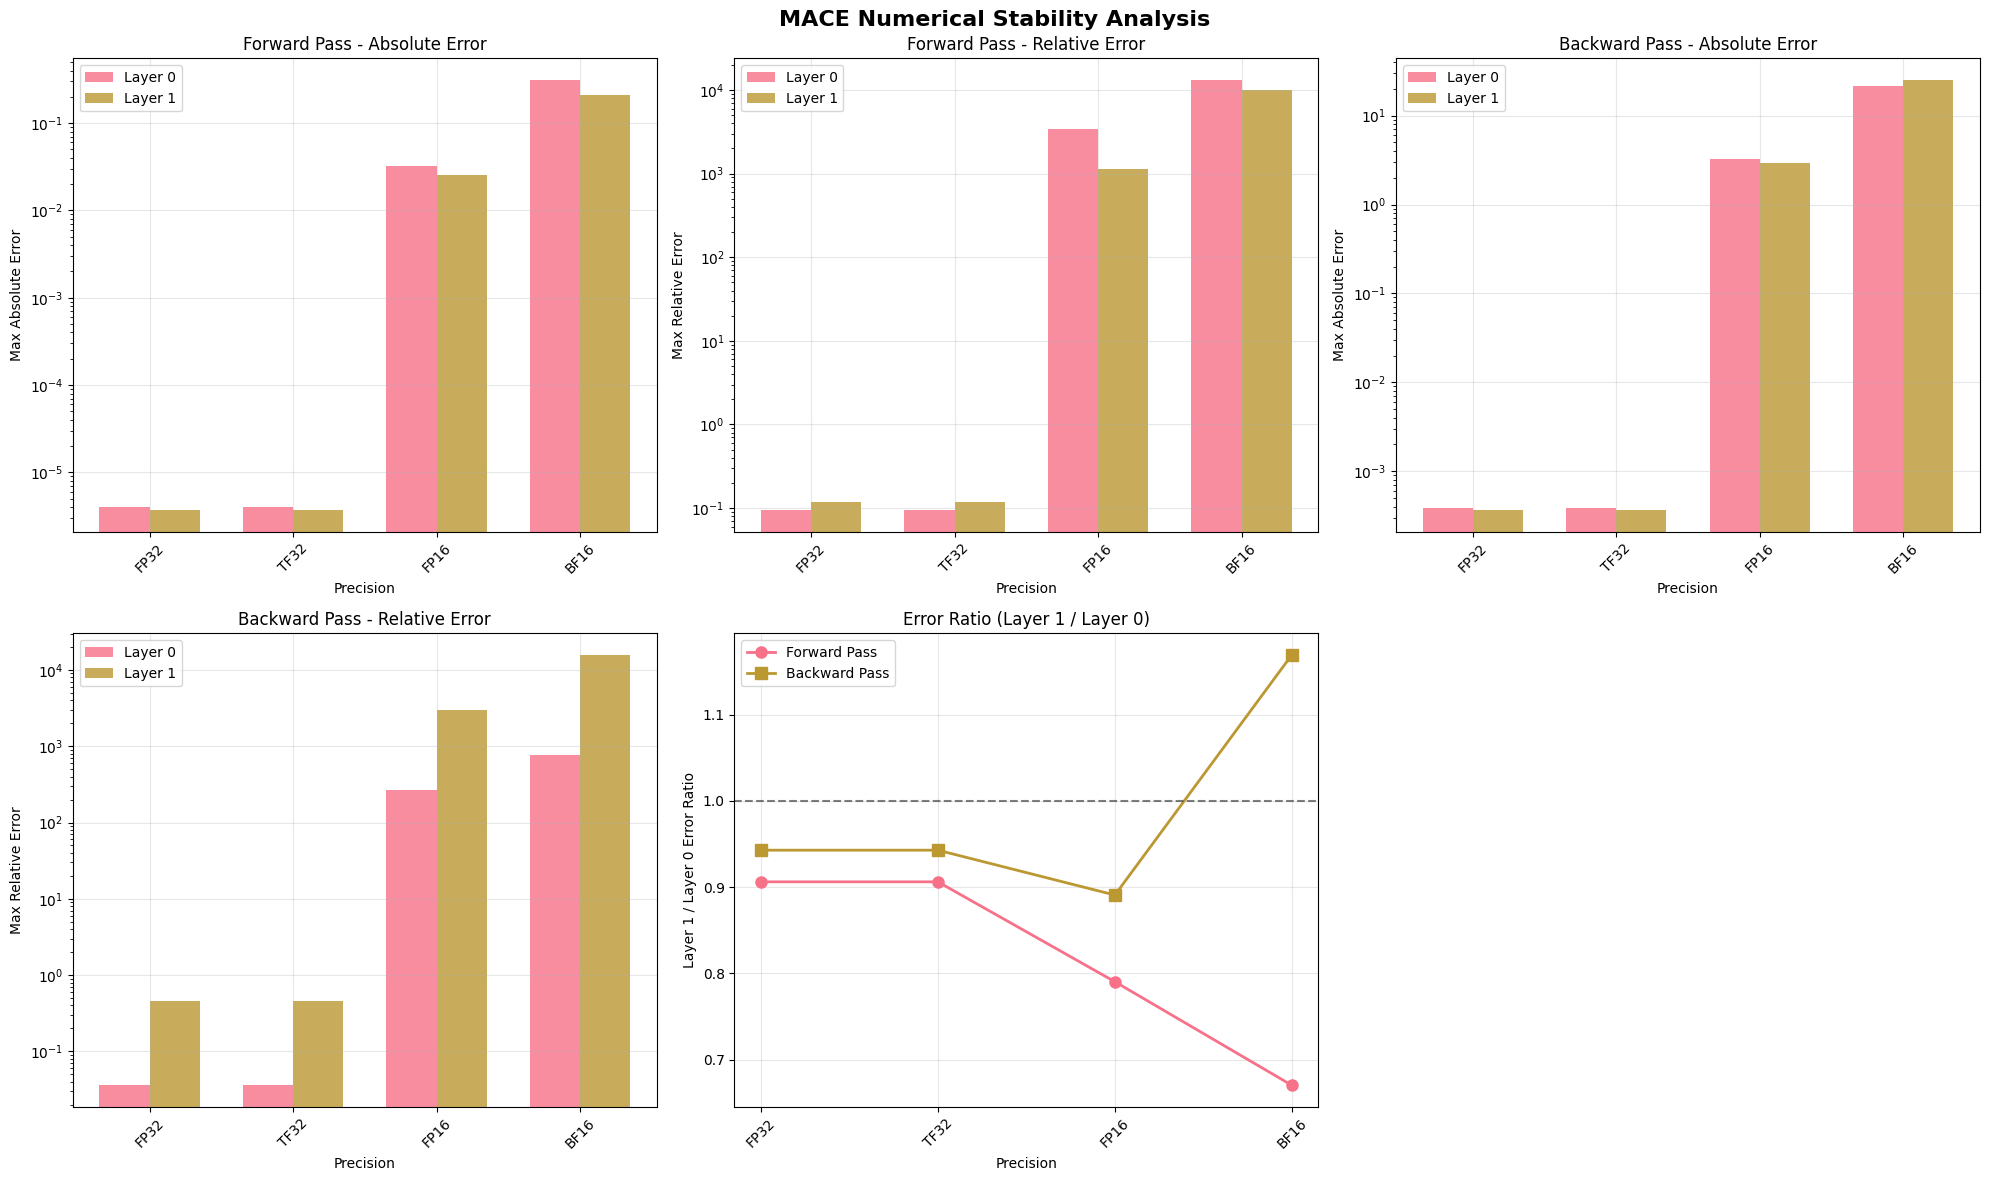

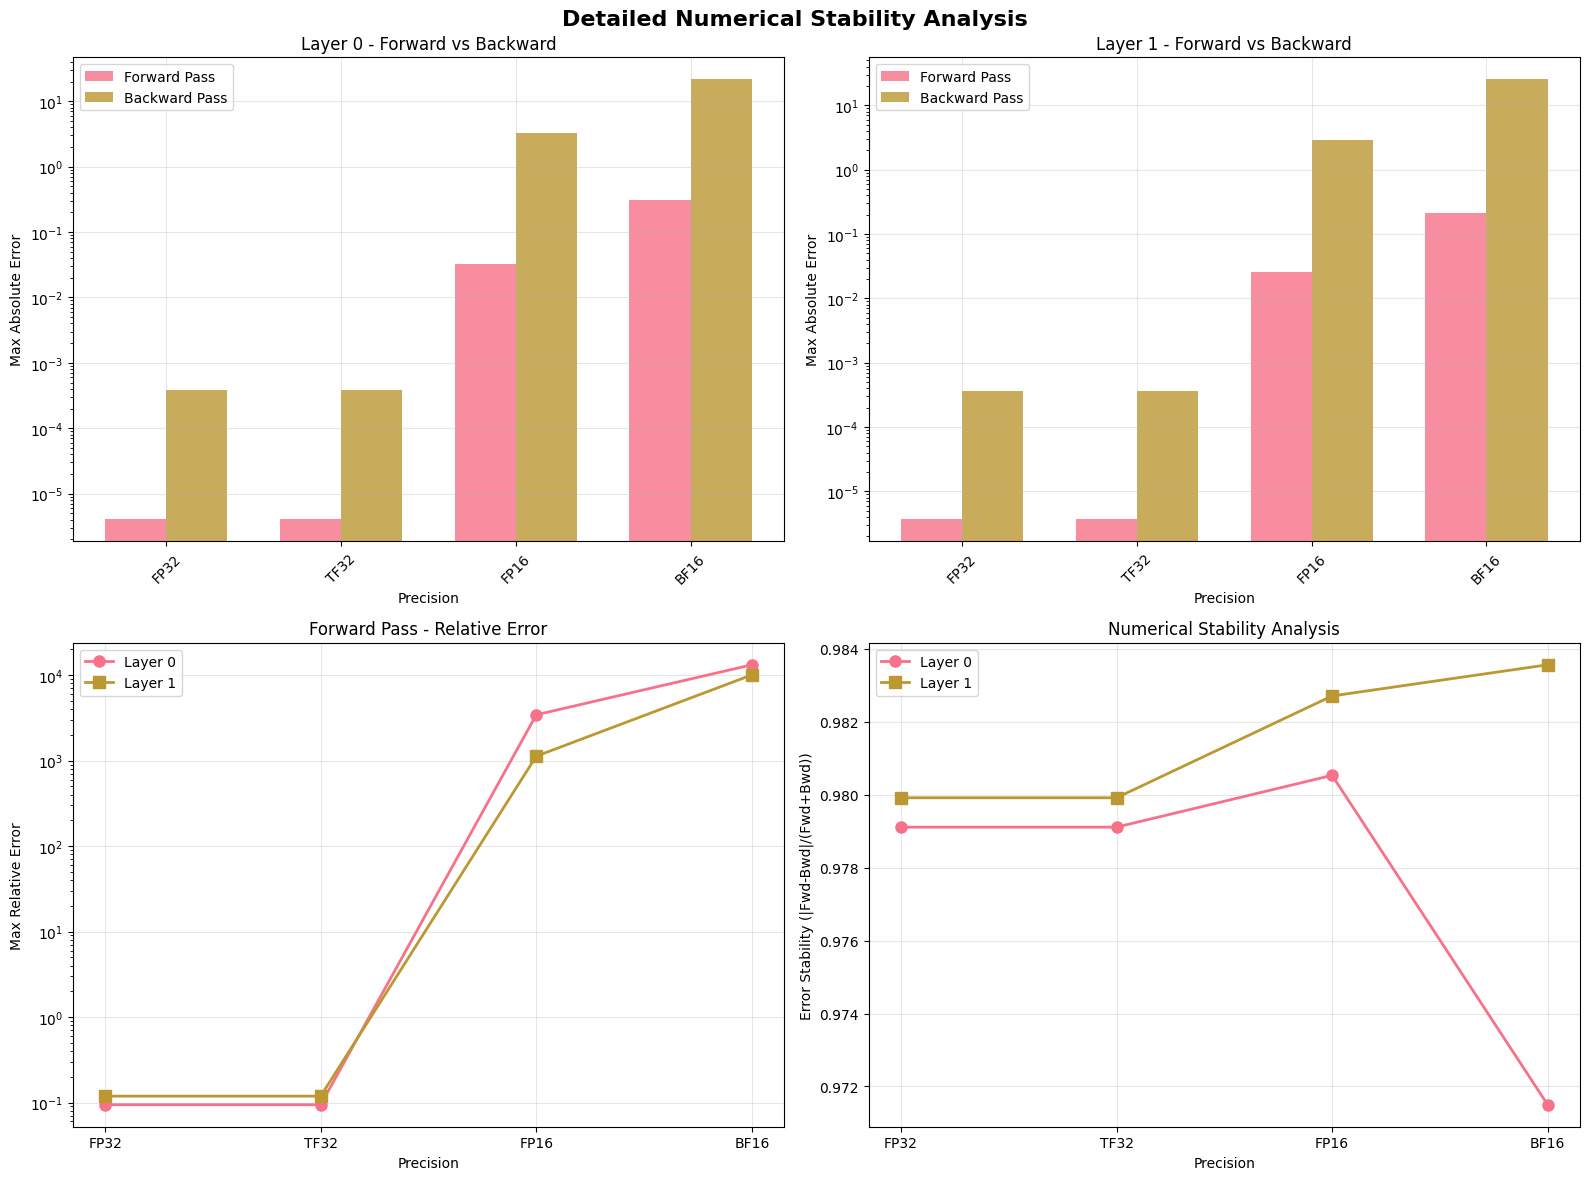


NUMERICAL STABILITY SUMMARY

Most Stable Precision (Layer 0):
  Forward Pass: FP32 (Error: 4.06e-06)
  Backward Pass: FP32 (Error: 3.85e-04)

Most Stable Precision (Layer 1):
  Forward Pass: FP32 (Error: 3.68e-06)
  Backward Pass: FP32 (Error: 3.63e-04)

Average Absolute Errors:
  FP32: 1.89e-04
  TF32: 1.89e-04
  FP16: 1.56e+00
  BF16: 1.19e+01

Least Stable Precision: BF16 (Max Error: 2.53e+01)

Layer Comparison:
  Layer 0 Average Error: 3.16e+00
  Layer 1 Average Error: 3.56e+00
  Layer 1 is 1.13x less stable than Layer 0


In [ ]:
import plotting_code as pc

# Example usage (add this to your notebook):
create_numerical_stability_plots(df_layer0_comparison, df_layer1_comparison)
create_detailed_error_analysis(df_layer0_comparison, df_layer1_comparison)
print_numerical_stability_summary(df_layer0_comparison, df_layer1_comparison) 

⁉️ Need to do the fp32 version of above

# Building a fully connected graph

That way the number of edges dim is (2, N^2)

In [ ]:
def get_fully_connected_edge_index(n_nodes: int) -> torch.Tensor:
    """Get edge_index for fully connected graph of n_nodes."""
    senders = []
    receivers = []
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j:  # Don't connect node to itself
                senders.append(i)
                receivers.append(j)
    return torch.stack([torch.tensor(senders), torch.tensor(receivers)], dim=0)


### segmented is still in fp64

Using device: cuda
Testing with 10 atoms (fully connected)...
  Max errors: FP32=1.09e-04, TF32=6.99e-05, FP16=2.60e-01, BF16=3.65e+00
Testing with 50 atoms (fully connected)...
  Max errors: FP32=5.53e-04, TF32=7.83e-04, FP16=4.71e+00, BF16=5.93e+01
Testing with 100 atoms (fully connected)...
  Max errors: FP32=1.56e-03, TF32=2.40e-03, FP16=1.47e+01, BF16=1.39e+02
Testing with 200 atoms (fully connected)...
  Max errors: FP32=6.20e-03, TF32=6.67e-03, FP16=4.06e+01, BF16=3.51e+02
Testing with 500 atoms (fully connected)...
  Max errors: FP32=2.73e-02, TF32=2.54e-02, FP16=1.96e+02, BF16=1.59e+03
Testing with 700 atoms (fully connected)...
  Max errors: FP32=7.25e-02, TF32=6.27e-02, FP16=3.47e+02, BF16=3.05e+03
Testing with 1000 atoms (fully connected)...
  Max errors: FP32=8.23e-02, TF32=9.01e-02, FP16=inf, BF16=4.72e+03
Testing with 2000 atoms (fully connected)...
  Max errors: FP32=3.11e-01, TF32=2.67e-01, FP16=inf, BF16=1.58e+04


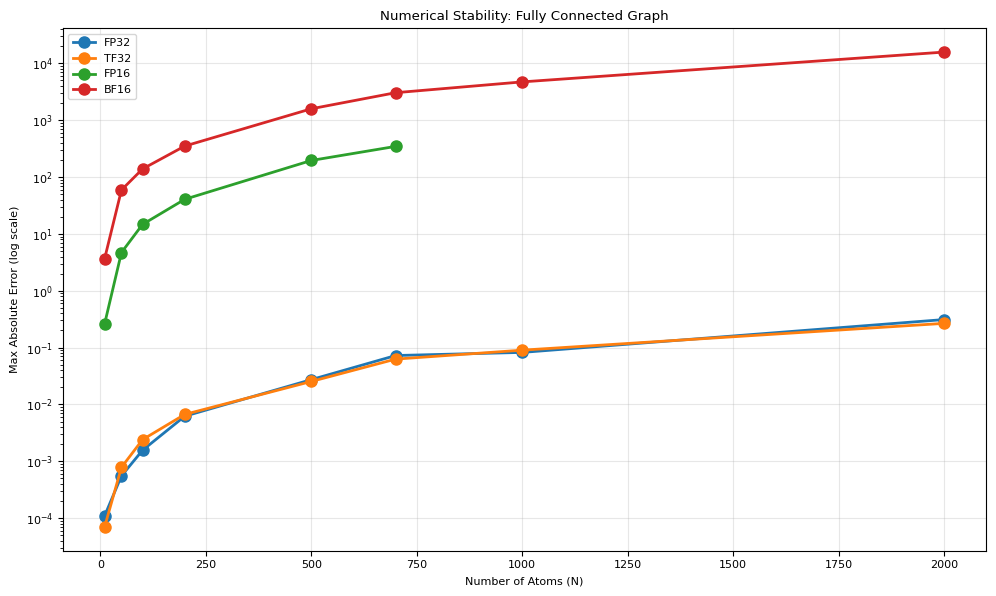


Error Summary (Fully Connected Graph):
 N_atoms     FP32     TF32       FP16         BF16
      10 0.000109 0.000070   0.260147     3.646112
      50 0.000553 0.000783   4.707056    59.264120
     100 0.001564 0.002402  14.694352   138.961333
     200 0.006204 0.006674  40.626471   350.934588
     500 0.027313 0.025360 195.802674  1589.380040
     700 0.072518 0.062726 346.541592  3050.111814
    1000 0.082302 0.090114        inf  4723.953145
    2000 0.311209 0.266771        inf 15806.670291


In [ ]:
# test different atoms

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
torch.manual_seed(0)

# we are building for the first layer and second layer
poly0 = make_poly(in_ir0, attr_ir0, out_ir0, math_dtype=torch.float64)
poly1 = make_poly(in_ir1, attr_ir1, out_ir1, math_dtype=torch.float64)

# fuse them with the helper function which is given by MACE in wrapper_ops.py
fused0_ref = with_cueq_conv_fusion(poly0)
fused1_ref = with_cueq_conv_fusion(poly1)

# cast layers once and store dtype
layers0, layers1 = {}, {}
for name, dtype in [
    ("FP64", torch.float64),
    ("FP32", torch.float32),
    ("TF32", torch.float32),
    ("FP16", torch.float16),
    ("BF16", torch.bfloat16),
]:
    if name in ("FP64", "FP32","FP16","BF16") and not device.startswith("cuda"):
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32   = False
    elif name == "TF32" and device.startswith("cuda"):
        dtype = torch.float32
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32   = True
        

    m0 = copy.deepcopy(fused0_ref).to(dtype)
    m1 = copy.deepcopy(fused1_ref).to(dtype)
    layers0[name] = (m0, dtype)
    layers1[name] = (m1, dtype)

# have many different numbers of atoms between 10 an 1000
n_atoms_list = [10, 50, 100, 200, 500, 700, 1000, 2000]

errors_by_prec = {p: [] for p in ["FP32", "TF32", "FP16", "BF16"]}
edge_counts = []

E = 1000000

for n_atoms in n_atoms_list:
    print(f"Testing with {n_atoms} atoms (fully connected)...")
    
    # Create fully connected edge index
    edge_index = get_fully_connected_edge_index(n_atoms).to(device)
    E = edge_index.shape[1]  # Number of edges = N^2
    edge_counts.append(E)
    
    # Create inputs for this graph size
    nf0_base = torch.randn(n_atoms, in_ir0.dim, dtype=torch.float64)
    nf1_base = torch.randn(n_atoms, in_ir1.dim, dtype=torch.float64)
    ea_base = torch.randn(E, attr_ir0.dim, dtype=torch.float64)
    tw0_base = torch.randn(E, tp0.weight_numel, dtype=torch.float64)
    tw1_base = torch.randn(E, tp1.weight_numel, dtype=torch.float64)


    
    # Create inputs for each precision
    inputs0, inputs1 = {}, {}
    for name, (layer0, dt0) in layers0.items():
        inputs0[name] = (
            nf0_base.clone().to(device=device, dtype=dt0).requires_grad_(),
            ea_base.clone().to(device=device, dtype=dt0),
            tw0_base.clone().to(device=device, dtype=dt0),
            edge_index
        )
        layer1, dt1 = layers1[name]
        inputs1[name] = (
            nf1_base.clone().to(device=device, dtype=dt1).requires_grad_(),
            ea_base.clone().to(device=device, dtype=dt1),
            tw1_base.clone().to(device=device, dtype=dt1),
            edge_index
        )
    
    # Run benchmark for this graph size
    results = {0: {}, 1: {}}
    
    # Run all precisions
    for name in ["FP64", "FP32", "TF32", "FP16", "BF16"]:

        torch.backends.cuda.matmul.allow_tf32 = (name=="TF32")
        torch.backends.cudnn.allow_tf32   = (name=="TF32")

        poly0 = make_poly(in_ir0, attr_ir0, out_ir0, torch.float64)
        poly1 = make_poly(in_ir1, attr_ir1, out_ir1, torch.float64)

        fused0_ref = with_cueq_conv_fusion(poly0)
        fused1_ref = with_cueq_conv_fusion(poly1)

        layer0, _ = layers0[name]
        layer1, _ = layers1[name]
    
        # Layer 0
        out0 = layer0(*inputs0[name])[0]
        loss0 = loss_fn(out0)
        loss0.backward()
        grad0 = inputs0[name][0].grad.detach()
        out0 = out0.detach()
        
        # Convert to float32 for numpy compatibility
        if name in ["FP16", "BF16"]:
            grad0 = grad0.float()
            out0 = out0.float()
        
        results[0][name] = {'out': out0.cpu().numpy(), 'grad': grad0.cpu().numpy()}
        
        # Clear gradients
        for p in layer0.parameters():
            if p.grad is not None:
                p.grad = None
        
        # Layer 1
        out1 = layer1(*inputs1[name])[0]
        loss1 = loss_fn(out1)
        loss1.backward()
        grad1 = inputs1[name][0].grad.detach()
        out1 = out1.detach()
        
        # Convert to float32 for numpy compatibility
        if name in ["FP16", "BF16"]:
            grad1 = grad1.float()
            out1 = out1.float()
        
        results[1][name] = {'out': out1.cpu().numpy(), 'grad': grad1.cpu().numpy()}
        
        # Clear gradients
        for p in layer1.parameters():
            if p.grad is not None:
                p.grad = None
    
    # Calculate errors for this graph size
    for name in ["FP32", "TF32", "FP16", "BF16"]:
        # Layer 0 errors
        out_err = np.abs(results[0]["FP64"]['out'] - results[0][name]['out']).max()
        grad_err = np.abs(results[0]["FP64"]['grad'] - results[0][name]['grad']).max()
        
        # Layer 1 errors  
        out_err_l1 = np.abs(results[1]["FP64"]['out'] - results[1][name]['out']).max()
        grad_err_l1 = np.abs(results[1]["FP64"]['grad'] - results[1][name]['grad']).max()
        
        # Store max error across both layers
        max_err = max(out_err, grad_err, out_err_l1, grad_err_l1)
        errors_by_prec[name].append(max_err)
    
    print(f"  Max errors: FP32={errors_by_prec['FP32'][-1]:.2e}, "
          f"TF32={errors_by_prec['TF32'][-1]:.2e}, "
          f"FP16={errors_by_prec['FP16'][-1]:.2e}, "
          f"BF16={errors_by_prec['BF16'][-1]:.2e}")


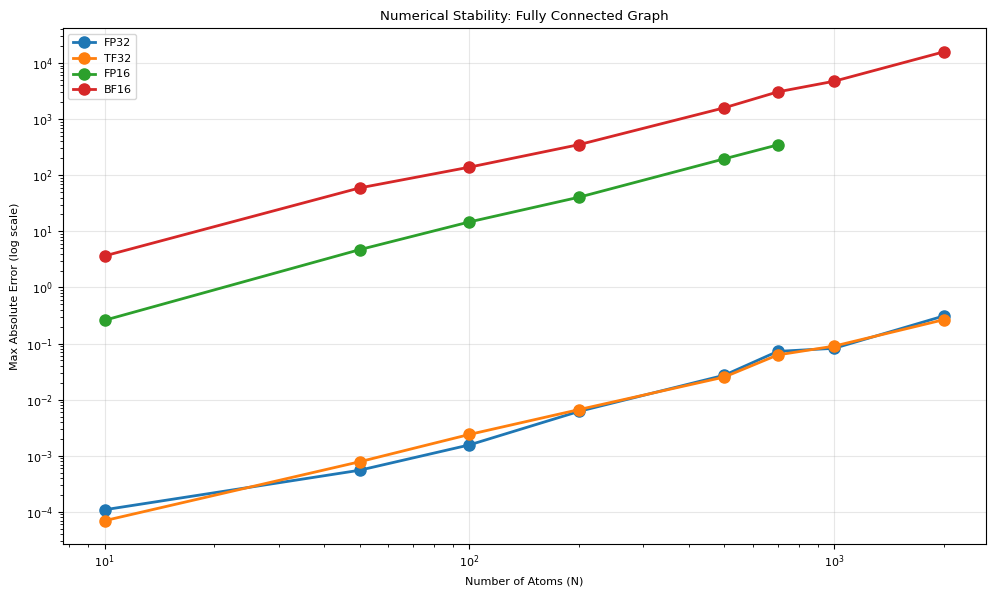


Error Summary (Fully Connected Graph):
 N_atoms     FP32     TF32       FP16         BF16
      10 0.000109 0.000070   0.260147     3.646112
      50 0.000553 0.000783   4.707056    59.264120
     100 0.001564 0.002402  14.694352   138.961333
     200 0.006204 0.006674  40.626471   350.934588
     500 0.027313 0.025360 195.802674  1589.380040
     700 0.072518 0.062726 346.541592  3050.111814
    1000 0.082302 0.090114        inf  4723.953145
    2000 0.311209 0.266771        inf 15806.670291


In [ ]:

# Create the plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for prec, errors in errors_by_prec.items():
    plt.loglog(n_atoms_list, errors, 'o-', label=prec, linewidth=2, markersize=8)

plt.xlabel('Number of Atoms (N)')
plt.ylabel('Max Absolute Error (log scale)')
plt.title('Numerical Stability: Fully Connected Graph')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Also show the data in a table
import pandas as pd
df_errors = pd.DataFrame({
    'N_atoms': n_atoms_list,
    'FP32': errors_by_prec['FP32'],
    'TF32': errors_by_prec['TF32'], 
    'FP16': errors_by_prec['FP16'],
    'BF16': errors_by_prec['BF16']
})
print("\nError Summary (Fully Connected Graph):")
print(df_errors.to_string(index=False))

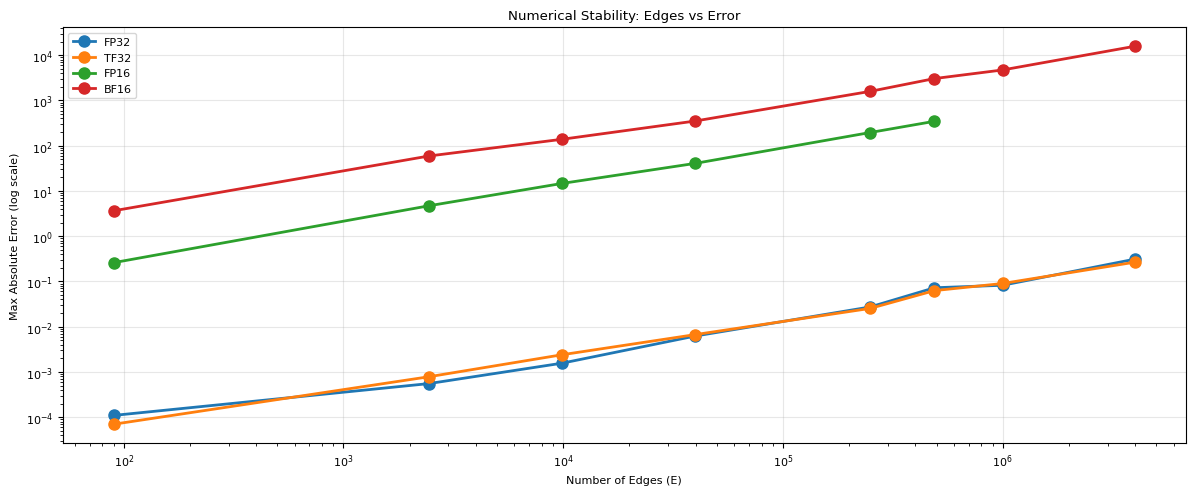


Error Summary (Fully Connected Graph):
 N_atoms  N_edges     FP32     TF32       FP16         BF16
      10       90 0.000109 0.000070   0.260147     3.646112
      50     2450 0.000553 0.000783   4.707056    59.264120
     100     9900 0.001564 0.002402  14.694352   138.961333
     200    39800 0.006204 0.006674  40.626471   350.934588
     500   249500 0.027313 0.025360 195.802674  1589.380040
     700   489300 0.072518 0.062726 346.541592  3050.111814
    1000   999000 0.082302 0.090114        inf  4723.953145
    2000  3998000 0.311209 0.266771        inf 15806.670291


In [ ]:
# Create the plots
import matplotlib.pyplot as plt

# Plot 1: Error vs Number of Atoms
plt.figure(figsize=(12, 5))

for prec, errors in errors_by_prec.items():
    plt.loglog(edge_counts, errors, 'o-', label=prec, linewidth=2, markersize=8)

plt.xlabel('Number of Edges (E)')
plt.ylabel('Max Absolute Error (log scale)')
plt.title('Numerical Stability: Edges vs Error')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Also show the data in a table
import pandas as pd
df_errors = pd.DataFrame({
    'N_atoms': n_atoms_list,
    'N_edges': edge_counts,
    'FP32': errors_by_prec['FP32'],
    'TF32': errors_by_prec['TF32'], 
    'FP16': errors_by_prec['FP16'],
    'BF16': errors_by_prec['BF16']
})
print("\nError Summary (Fully Connected Graph):")
print(df_errors.to_string(index=False))